# v9 — Return-first multi-task forecasting

## tl;dr — executed result

This notebook executed successfully on **184 held-out SPY sessions from 2026-01-02 through 2026-09-25**.

| Model | Return RMSE | RMSE skill vs zero | Direction | Delta IC |
| --- | ---: | ---: | ---: | ---: |
| Zero return | 0.8337% | 0.00% | 48.37% | — |
| Ridge | 0.8614% | -3.32% | 47.83% | 0.0175 |
| **v9 multi-task LSTM** | **0.8279%** | **+0.70%** | **54.35%** | **0.0934** |

The point estimate is encouraging but deliberately modest: v9 beats the zero-return baseline by **+0.70% RMSE skill** in this single 2026 SPY holdout. Its direction head is 51.63% accurate and its nominal 80% interval covers 70.11% of test returns, so the uncertainty head is currently **under-calibrated**.

This is a worked example, not evidence of a persistent trading edge. The next requirement is to run the same v9 protocol across the multi-asset/multi-regime arena.


## Context & Methods

     ### Architecture

     ```text
                      LAST 30 TRADING SESSIONS
                               │
              stationary / scale-aware features
                               │
     ┌─────────────────────────┼─────────────────────────┐
     │                         │                         │
log return                  volatility                momentum
     │                         │                         │
     └─────────────────────────┼─────────────────────────┘
                               │
                        train-only scaling
                               │
                               ▼
                  ┌────────────────────────┐
                  │    SHARED ENCODER      │
                  │   LSTM 64 → LSTM 32    │
                  └───────────┬────────────┘
                              │
           ┌──────────────────┼──────────────────┐
           │                  │                  │
           ▼                  ▼                  ▼
    DIRECTION HEAD      RETURN HEAD       QUANTILE HEAD
       P(up)            E[r(t+1)]        q10 / q50 / q90
           │                  │                  │
           └──────────────────┼──────────────────┘
                              ▼
                      HELD-OUT 2026 TEST
                              │
           ┌──────────────────┼──────────────────┐
           ▼                  ▼                  ▼
       Zero return          Ridge               v9
     ```

     ### Key Assumptions

     - Features at date **t** only use observations available through **t**.
     - The target is the next session's log return, **t+1**.
     - Feature scaling is fit on the training partition only.
     - Train: targets before 2025; validation: 2025 targets; test: 2026 targets.
     - Validation controls early stopping. Test observations never select model weights.
     - The notebook uses a frozen CSV when present; otherwise it downloads SPY from Yahoo Finance and writes that snapshot.
     - Transaction-cost results are diagnostics, not an execution simulator.

In [1]:
from __future__ import annotations

import json
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import yfinance as yf
from IPython.display import display
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM, Lambda
from tensorflow.keras.losses import Huber
from tensorflow.keras.optimizers import Adam

SEED = 42
WINDOW = 30
TRAIN_END = pd.Timestamp("2025-01-01")
VALIDATION_END = pd.Timestamp("2026-01-01")
DATA_END = "2026-09-27"
MAX_EPOCHS = 20
BATCH_SIZE = 64
TRANSACTION_COST_BPS = 5.0

ROOT = Path.cwd().resolve()
while ROOT.parent != ROOT and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if not (ROOT / "pyproject.toml").exists():
    raise RuntimeError("Run the notebook from inside the repository")

DATA_PATH = ROOT / "examples" / "data" / "v9_spy_2015_2026.csv"
OUTPUT_DIR = ROOT / "reports" / "generated" / "v9-notebook"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"Window: {WINDOW} sessions")
print(f"Train targets: < {TRAIN_END.date()}")
print(f"Validation targets: 2025")
print(f"Test targets: 2026")

2026-09-27 04:38:40.122518: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1790483920.134161    2232 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1790483920.137523    2232 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.1
Window: 30 sessions
Train targets: < 2025-01-01
Validation targets: 2025
Test targets: 2026


## Data

### 1. Load or freeze SPY adjusted close

In [2]:
def load_close() -> pd.Series:
    if DATA_PATH.exists():
        frame = pd.read_csv(DATA_PATH, parse_dates=["Date"])
        close = frame.set_index("Date")["Close"].astype(float)
        source = f"frozen CSV: {DATA_PATH.relative_to(ROOT)}"
    else:
        last_error = None
        for attempt in range(1, 4):
            try:
                frame = yf.download(
                    "SPY",
                    start="2015-01-01",
                    end=DATA_END,
                    auto_adjust=True,
                    progress=False,
                    threads=False,
                )
                if frame.empty:
                    raise RuntimeError("Yahoo Finance returned no SPY data")
                close = frame["Close"]
                if isinstance(close, pd.DataFrame):
                    close = close.iloc[:, 0]
                close = pd.to_numeric(close, errors="coerce").dropna().astype(float)
                close.index = pd.to_datetime(close.index).tz_localize(None)
                close.index.name = "Date"
                close.rename("Close").to_frame().to_csv(DATA_PATH)
                source = f"Yahoo Finance; frozen to {DATA_PATH.relative_to(ROOT)}"
                break
            except Exception as exc:
                last_error = exc
                if attempt == 3:
                    raise
                time.sleep(5 * attempt)
        else:
            raise RuntimeError(last_error)
    close = close.sort_index()
    close.name = "Close"
    print(source)
    print(f"{close.index.min().date()} → {close.index.max().date()} | {len(close):,} observations")
    return close

close = load_close()
display(close.tail().to_frame())

frozen CSV: examples/data/v9_spy_2015_2026.csv
2015-01-02 → 2026-09-25 | 2,950 observations


,Close
Date,
2026-09-21,773.500000
2026-09-22,773.380005
2026-09-23,767.809998
2026-09-24,767.179993
2026-09-25,771.349976


### 2. Build stationary features and next-session target

In [3]:
features = pd.DataFrame(index=close.index)
features["log_return_pct"] = 100.0 * np.log(close / close.shift(1))
features["vol_5_pct"] = features["log_return_pct"].rolling(5).std()
features["vol_20_pct"] = features["log_return_pct"].rolling(20).std()
features["momentum_5_pct"] = 100.0 * np.log(close / close.shift(5))
features["momentum_20_pct"] = 100.0 * np.log(close / close.shift(20))
features["distance_sma20_pct"] = 100.0 * (close / close.rolling(20).mean() - 1.0)

research = features.copy()
research["target_return_pct"] = features["log_return_pct"].shift(-1)
research["target_date"] = research.index.to_series().shift(-1)
research["target_close"] = close.shift(-1)
research["current_close"] = close
research = research.dropna().copy()

FEATURE_COLUMNS = list(features.columns)
print("Features:", FEATURE_COLUMNS)
display(research.tail(5))

Features: ['log_return_pct', 'vol_5_pct', 'vol_20_pct', 'momentum_5_pct', 'momentum_20_pct', 'distance_sma20_pct']


,log_return_pct,vol_5_pct,vol_20_pct,momentum_5_pct,momentum_20_pct,distance_sma20_pct,target_return_pct,target_date,target_close,current_close
Date,,,,,,,,,,
2026-09-18,0.128613,0.687878,0.576938,-0.092749,0.128613,-0.106834,1.538602,2026-09-21,773.500000,761.690002
2026-09-21,1.538602,0.914476,0.666746,1.893017,1.258927,1.377681,-0.015514,2026-09-22,773.380005,773.500000
2026-09-22,-0.015514,0.830380,0.661781,2.337232,1.537688,1.283626,-0.722822,2026-09-23,767.809998,773.380005
2026-09-23,-0.722822,0.912697,0.682400,2.056374,0.495782,0.529169,-0.082086,2026-09-24,767.179993,767.809998
2026-09-24,-0.082086,0.832147,0.682819,0.846792,0.391498,0.426975,0.542075,2026-09-25,771.349976,767.179993


### 3. Fit preprocessing on training rows only

In [4]:
train_row_mask = research["target_date"] < TRAIN_END
feature_scaler = StandardScaler()
feature_scaler.fit(research.loc[train_row_mask, FEATURE_COLUMNS])

scaled_features = pd.DataFrame(
    feature_scaler.transform(research[FEATURE_COLUMNS]),
    index=research.index,
    columns=FEATURE_COLUMNS,
)

def make_sequences():
    x, y_return, y_direction = [], [], []
    target_dates, current_close_values, target_close_values = [], [], []
    for i in range(WINDOW - 1, len(research)):
        x.append(
            scaled_features.iloc[i - WINDOW + 1 : i + 1].to_numpy(dtype=np.float32)
        )
        target_return = float(research.iloc[i]["target_return_pct"])
        y_return.append(target_return)
        y_direction.append(float(target_return > 0.0))
        target_dates.append(pd.Timestamp(research.iloc[i]["target_date"]))
        current_close_values.append(float(research.iloc[i]["current_close"]))
        target_close_values.append(float(research.iloc[i]["target_close"]))
    return (
        np.asarray(x, dtype=np.float32),
        np.asarray(y_return, dtype=np.float32),
        np.asarray(y_direction, dtype=np.float32),
        pd.DatetimeIndex(target_dates),
        np.asarray(current_close_values, dtype=float),
        np.asarray(target_close_values, dtype=float),
    )

x, y_return, y_direction, target_dates, current_close_values, target_close_values = make_sequences()

train_mask = target_dates < TRAIN_END
validation_mask = (target_dates >= TRAIN_END) & (target_dates < VALIDATION_END)
test_mask = target_dates >= VALIDATION_END

x_train, y_train, d_train = x[train_mask], y_return[train_mask], y_direction[train_mask]
x_val, y_val, d_val = x[validation_mask], y_return[validation_mask], y_direction[validation_mask]
x_test, y_test, d_test = x[test_mask], y_return[test_mask], y_direction[test_mask]

test_dates = target_dates[test_mask]
test_current_close = current_close_values[test_mask]
test_target_close = target_close_values[test_mask]

split_table = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "samples": [len(x_train), len(x_val), len(x_test)],
    "first_target": [
        target_dates[train_mask].min(),
        target_dates[validation_mask].min(),
        target_dates[test_mask].min(),
    ],
    "last_target": [
        target_dates[train_mask].max(),
        target_dates[validation_mask].max(),
        target_dates[test_mask].max(),
    ],
})
display(split_table)

,split,samples,first_target,last_target
0,train,2466,2015-03-17,2024-12-31
1,validation,250,2025-01-02,2025-12-31
2,test,184,2026-01-02,2026-09-25


## Results

### 4. Baselines: zero return and Ridge

In [5]:
zero_prediction = np.zeros_like(y_test)

ridge = Ridge(alpha=10.0)
ridge.fit(x_train.reshape(len(x_train), -1), y_train)
ridge_prediction = ridge.predict(x_test.reshape(len(x_test), -1)).astype(float)

print(f"Ridge coefficients: {ridge.coef_.size:,}")
print(f"Ridge train R²: {ridge.score(x_train.reshape(len(x_train), -1), y_train):.4f}")

Ridge coefficients: 180
Ridge train R²: 0.1347


### 5. Build v9 multi-task LSTM

In [6]:
QUANTILES = tf.constant([0.10, 0.50, 0.90], dtype=tf.float32)

def pinball_loss(y_true, y_pred):
    y_true = tf.cast(tf.reshape(y_true, (-1, 1)), tf.float32)
    error = y_true - y_pred
    return tf.reduce_mean(
        tf.maximum(QUANTILES * error, (QUANTILES - 1.0) * error)
    )

def build_v9(input_shape) -> Model:
    inputs = Input(shape=input_shape, name="market_window")
    shared = LSTM(64, return_sequences=True, name="shared_lstm_1")(inputs)
    shared = Dropout(0.10, name="shared_dropout_1")(shared)
    shared = LSTM(32, name="shared_lstm_2")(shared)
    shared = Dropout(0.10, name="shared_dropout_2")(shared)

    direction = Dense(1, activation="sigmoid", name="direction")(shared)
    expected_return = Dense(1, activation="linear", name="expected_return")(shared)
    raw_quantiles = Dense(3, activation="linear", name="raw_quantiles")(shared)
    quantiles = Lambda(
        lambda values: tf.sort(values, axis=-1),
        name="quantiles",
    )(raw_quantiles)

    return Model(
        inputs=inputs,
        outputs={
            "direction": direction,
            "expected_return": expected_return,
            "quantiles": quantiles,
        },
        name="return_multitask_lstm_v9",
    )

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)
v9 = build_v9((x_train.shape[1], x_train.shape[2]))
v9.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss={
        "direction": "binary_crossentropy",
        "expected_return": Huber(),
        "quantiles": pinball_loss,
    },
    loss_weights={
        "direction": 0.25,
        "expected_return": 1.0,
        "quantiles": 0.50,
    },
    metrics={
        "direction": ["accuracy"],
        "expected_return": ["mae"],
        "quantiles": [],
    },
)
v9.summary()

2026-09-27 04:38:42.899400: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "return_multitask_lstm_v9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ market_window       │ (None, 30, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_lstm_1       │ (None, 30, 64)    │     18,176 │ market_window[0]… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout_1    │ (None, 30, 64)    │          0 │ shared_lstm_1[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_lstm_2       │ (None, 32)        │     12,416 │ shared_dropout_1… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout_2    │ (None, 32)        │          0 │ shared_lstm_2[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ raw_quantiles       │ (None, 3)         │         99 │ shared_dropout_2… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ direction (Dense)   │ (None, 1)         │         33 │ shared_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expected_return     │ (None, 1)         │         33 │ shared_dropout_2… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quantiles (Lambda)  │ (None, 3)         │          0 │ raw_quantiles[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 30,757 (120.14 KB)

 Trainable params: 30,757 (120.14 KB)

 Non-trainable params: 0 (0.00 B)

### 6. Train chronologically with 2025 validation

In [7]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1,
    ),
]

history = v9.fit(
    x_train,
    {
        "direction": d_train,
        "expected_return": y_train,
        "quantiles": y_train,
    },
    validation_data=(
        x_val,
        {
            "direction": d_val,
            "expected_return": y_val,
            "quantiles": y_val,
        },
    ),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=False,
    callbacks=callbacks,
    verbose=0,
)

best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
print(f"Epochs executed: {len(history.history['loss'])}")
print(f"Best validation-loss epoch: {best_epoch}")
print(f"Best validation loss: {min(history.history['val_loss']):.6f}")


Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.



Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


Epoch 16: early stopping


Restoring model weights from the end of the best epoch: 13.


Epochs executed: 16
Best validation-loss epoch: 13
Best validation loss: 0.701396


### 7. Held-out 2026 predictions

In [8]:
v9_output = v9.predict(x_test, verbose=0)
v9_prediction = np.asarray(v9_output["expected_return"]).reshape(-1)
v9_direction_probability = np.asarray(v9_output["direction"]).reshape(-1)
v9_quantiles = np.asarray(v9_output["quantiles"])

def information_coefficient(actual, predicted):
    if np.std(actual) == 0 or np.std(predicted) == 0:
        return np.nan
    return float(np.corrcoef(actual, predicted)[0, 1])

def evaluate_forecast(name, prediction):
    error = np.asarray(prediction) - y_test
    rmse = float(np.sqrt(np.mean(error ** 2)))
    mae = float(np.mean(np.abs(error)))
    direction_accuracy = float(
        np.mean((np.asarray(prediction) > 0) == (y_test > 0))
    )
    ic = information_coefficient(y_test, prediction)
    zero_rmse = float(np.sqrt(np.mean(y_test ** 2)))
    skill = 1.0 - rmse / zero_rmse
    return {
        "model": name,
        "return_rmse_pct": rmse,
        "return_mae_pct": mae,
        "direction_accuracy": direction_accuracy,
        "delta_ic": ic,
        "rmse_skill_vs_zero": skill,
    }

summary = pd.DataFrame([
    evaluate_forecast("Zero return", zero_prediction),
    evaluate_forecast("Ridge", ridge_prediction),
    evaluate_forecast("v9 multi-task LSTM", v9_prediction),
])

coverage_80 = float(
    np.mean((y_test >= v9_quantiles[:, 0]) & (y_test <= v9_quantiles[:, 2]))
)
mean_interval_width = float(
    np.mean(v9_quantiles[:, 2] - v9_quantiles[:, 0])
)
direction_head_accuracy = float(
    np.mean((v9_direction_probability >= 0.5) == (y_test > 0))
)

display(summary.round(6))
print()
for row in summary.to_dict(orient="records"):
    print(
        f"{row['model']:<20} "
        f"RMSE={row['return_rmse_pct']:.4f}%  "
        f"skill={row['rmse_skill_vs_zero']:+.2%}  "
        f"direction={row['direction_accuracy']:.2%}  "
        f"IC={row['delta_ic']:.4f}"
    )
print(f"v9 direction-head accuracy: {direction_head_accuracy:.2%}")
print(f"Nominal 80% quantile interval coverage: {coverage_80:.2%}")
print(f"Mean q10-q90 interval width: {mean_interval_width:.3f} percentage points")

,model,return_rmse_pct,return_mae_pct,direction_accuracy,delta_ic,rmse_skill_vs_zero
0,Zero return,0.833713,0.637573,0.483696,NaN,0.000000
1,Ridge,0.861433,0.661904,0.478261,0.017466,-0.033249
2,v9 multi-task LSTM,0.827883,0.629663,0.543478,0.093361,0.006992



Zero return          RMSE=0.8337%  skill=+0.00%  direction=48.37%  IC=nan
Ridge                RMSE=0.8614%  skill=-3.32%  direction=47.83%  IC=0.0175
v9 multi-task LSTM   RMSE=0.8279%  skill=+0.70%  direction=54.35%  IC=0.0934
v9 direction-head accuracy: 51.63%
Nominal 80% quantile interval coverage: 70.11%
Mean q10-q90 interval width: 1.696 percentage points


### 8. Architecture diagram

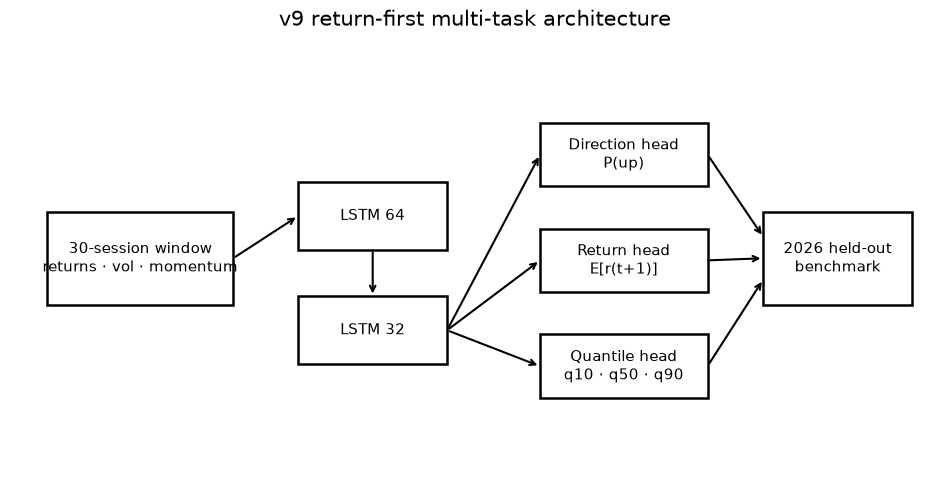

In [9]:
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.axis("off")

boxes = {
    "features": (0.04, 0.39, 0.20, 0.22, "30-session window\nreturns · vol · momentum"),
    "lstm1": (0.31, 0.52, 0.16, 0.16, "LSTM 64"),
    "lstm2": (0.31, 0.25, 0.16, 0.16, "LSTM 32"),
    "direction": (0.57, 0.67, 0.18, 0.15, "Direction head\nP(up)"),
    "return": (0.57, 0.42, 0.18, 0.15, "Return head\nE[r(t+1)]"),
    "quantile": (0.57, 0.17, 0.18, 0.15, "Quantile head\nq10 · q50 · q90"),
    "eval": (0.81, 0.39, 0.16, 0.22, "2026 held-out\nbenchmark"),
}

for x0, y0, width, height, label in boxes.values():
    rect = plt.Rectangle((x0, y0), width, height, fill=False, linewidth=1.8)
    ax.add_patch(rect)
    ax.text(
        x0 + width / 2,
        y0 + height / 2,
        label,
        ha="center",
        va="center",
        fontsize=11,
    )

def arrow(start, end):
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops={"arrowstyle": "->", "lw": 1.5},
    )

arrow((0.24, 0.50), (0.31, 0.60))
arrow((0.39, 0.52), (0.39, 0.41))
arrow((0.47, 0.33), (0.57, 0.745))
arrow((0.47, 0.33), (0.57, 0.495))
arrow((0.47, 0.33), (0.57, 0.245))
arrow((0.75, 0.745), (0.81, 0.55))
arrow((0.75, 0.495), (0.81, 0.50))
arrow((0.75, 0.245), (0.81, 0.45))

ax.set_title("v9 return-first multi-task architecture", fontsize=15, pad=15)
plt.show()

### 9. Forecast quality on the held-out period

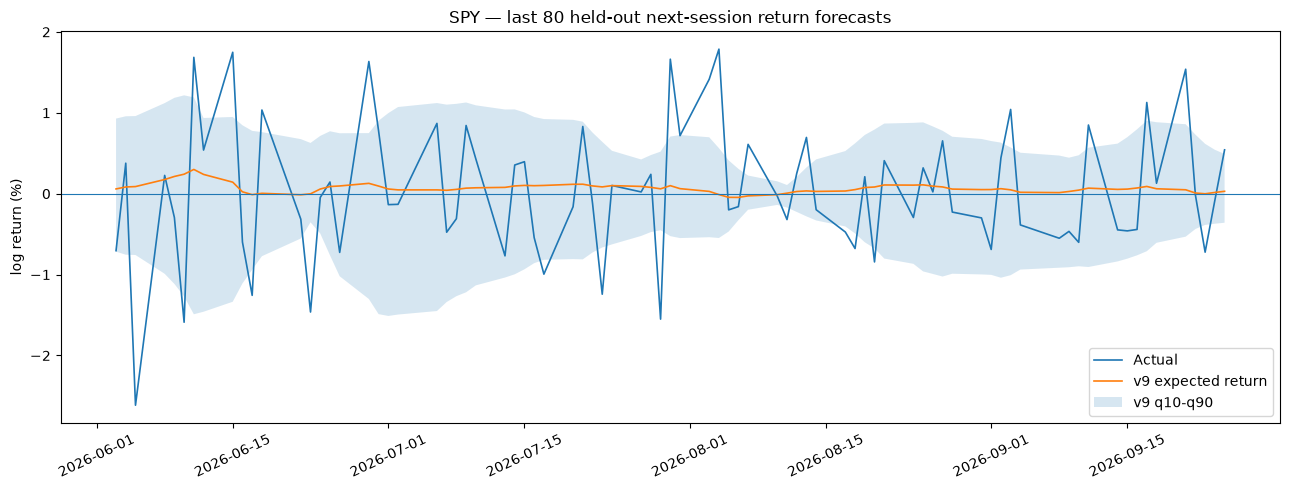

In [10]:
plot_frame = pd.DataFrame(
    {
        "Actual next-session return": y_test,
        "Ridge": ridge_prediction,
        "v9": v9_prediction,
        "q10": v9_quantiles[:, 0],
        "q90": v9_quantiles[:, 2],
    },
    index=test_dates,
)
recent = plot_frame.tail(80)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(
    recent.index,
    recent["Actual next-session return"],
    label="Actual",
    linewidth=1.2,
)
ax.plot(
    recent.index,
    recent["v9"],
    label="v9 expected return",
    linewidth=1.2,
)
ax.fill_between(
    recent.index,
    recent["q10"],
    recent["q90"],
    alpha=0.18,
    label="v9 q10-q90",
)
ax.axhline(0.0, linewidth=0.8)
ax.set_title("SPY — last 80 held-out next-session return forecasts")
ax.set_ylabel("log return (%)")
ax.legend()
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

### 10. Cost-aware directional diagnostic

,strategy,sharpe,max_drawdown,average_turnover,final_return
0,Ridge sign,-0.717210,-0.135876,1.059783,-0.073418
1,v9 sign,1.692115,-0.088850,0.092391,0.169679


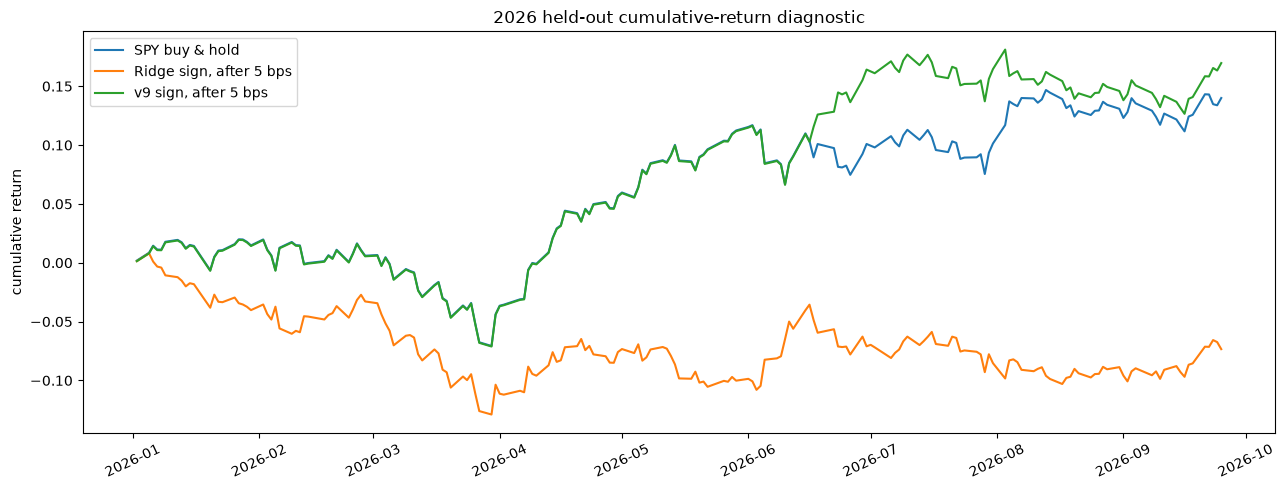

In [11]:
actual_simple_returns = np.expm1(y_test / 100.0)
cost_rate = TRANSACTION_COST_BPS / 10_000.0

def strategy_series(prediction):
    position = np.where(np.asarray(prediction) > 0, 1.0, -1.0)
    previous_position = np.r_[0.0, position[:-1]]
    turnover = np.abs(position - previous_position)
    strategy_return = position * actual_simple_returns - cost_rate * turnover
    cumulative = np.cumprod(1.0 + strategy_return) - 1.0
    annualized_vol = float(np.std(strategy_return, ddof=1) * np.sqrt(252))
    annualized_return = float(np.mean(strategy_return) * 252)
    sharpe = annualized_return / annualized_vol if annualized_vol > 0 else 0.0
    peak = np.maximum.accumulate(1.0 + cumulative)
    drawdown = (1.0 + cumulative) / peak - 1.0
    return (
        position,
        strategy_return,
        cumulative,
        sharpe,
        float(drawdown.min()),
        float(np.mean(turnover)),
    )

ridge_strategy = strategy_series(ridge_prediction)
v9_strategy = strategy_series(v9_prediction)
buy_hold_cumulative = np.cumprod(1.0 + actual_simple_returns) - 1.0

strategy_summary = pd.DataFrame([
    {
        "strategy": "Ridge sign",
        "sharpe": ridge_strategy[3],
        "max_drawdown": ridge_strategy[4],
        "average_turnover": ridge_strategy[5],
        "final_return": ridge_strategy[2][-1],
    },
    {
        "strategy": "v9 sign",
        "sharpe": v9_strategy[3],
        "max_drawdown": v9_strategy[4],
        "average_turnover": v9_strategy[5],
        "final_return": v9_strategy[2][-1],
    },
])
display(strategy_summary.round(6))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_dates, buy_hold_cumulative, label="SPY buy & hold")
ax.plot(test_dates, ridge_strategy[2], label="Ridge sign, after 5 bps")
ax.plot(test_dates, v9_strategy[2], label="v9 sign, after 5 bps")
ax.set_title("2026 held-out cumulative-return diagnostic")
ax.set_ylabel("cumulative return")
ax.legend()
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Takeaways

The cells above are intentionally evidence-first:

- **Return RMSE skill vs zero** answers whether the model improves on "tomorrow's return = 0".
- **Ridge** checks whether the neural network is adding anything beyond a simple linear model on the same information.
- **Direction accuracy and IC** test whether the sign/ranking signal is useful.
- **q10-q90 coverage** tests whether the uncertainty head behaves plausibly.
- The cost-aware strategy is shown only as a diagnostic; it is not evidence of deployable trading performance by itself.

An unimpressive result is still useful: it tells us to improve the target/features/model rather than rely on a visually convincing price chart.

In [12]:
result_payload = {
    "seed": SEED,
    "window": WINDOW,
    "train_samples": int(len(x_train)),
    "validation_samples": int(len(x_val)),
    "test_samples": int(len(x_test)),
    "test_start": str(test_dates.min().date()),
    "test_end": str(test_dates.max().date()),
    "best_epoch": best_epoch,
    "forecast_metrics": summary.to_dict(orient="records"),
    "direction_head_accuracy": direction_head_accuracy,
    "interval_80_coverage": coverage_80,
    "interval_mean_width_pct": mean_interval_width,
    "ridge_strategy": {
        "sharpe": ridge_strategy[3],
        "max_drawdown": ridge_strategy[4],
        "average_turnover": ridge_strategy[5],
        "final_return": float(ridge_strategy[2][-1]),
    },
    "v9_strategy": {
        "sharpe": v9_strategy[3],
        "max_drawdown": v9_strategy[4],
        "average_turnover": v9_strategy[5],
        "final_return": float(v9_strategy[2][-1]),
    },
}
metrics_path = OUTPUT_DIR / "v9_spy_metrics.json"
metrics_path.write_text(
    json.dumps(result_payload, indent=2),
    encoding="utf-8",
)
print(json.dumps(result_payload, indent=2))

{
  "seed": 42,
  "window": 30,
  "train_samples": 2466,
  "validation_samples": 250,
  "test_samples": 184,
  "test_start": "2026-01-02",
  "test_end": "2026-09-25",
  "best_epoch": 13,
  "forecast_metrics": [
    {
      "model": "Zero return",
      "return_rmse_pct": 0.8337128758430481,
      "return_mae_pct": 0.6375728845596313,
      "direction_accuracy": 0.483695652173913,
      "delta_ic": NaN,
      "rmse_skill_vs_zero": 0.0
    },
    {
      "model": "Ridge",
      "return_rmse_pct": 0.8614329041201658,
      "return_mae_pct": 0.6619036472351898,
      "direction_accuracy": 0.4782608695652174,
      "delta_ic": 0.01746564579553744,
      "rmse_skill_vs_zero": -0.03324889069163928
    },
    {
      "model": "v9 multi-task LSTM",
      "return_rmse_pct": 0.8278833627700806,
      "return_mae_pct": 0.629663348197937,
      "direction_accuracy": 0.5434782608695652,
      "delta_ic": 0.09336097926930373,
      "rmse_skill_vs_zero": 0.0069922310688469436
    }
  ],
  "direction_h